# Get data to analyze

tldr attach files on left sidebar
1. Click on folder icon (Files)
2. Wait until notebook is connected to runtime
3. Drag and drop your results csv file.

In [ ]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

pd.set_option('display.max_columns', None)

In [ ]:
!ls  # list files in current directory

572919_2afc_gratings_blocks_2026-04-13_12h48.25.018.csv  sample_data


In [ ]:
# load file above. In my case
df = pd.read_csv('572919_2afc_gratings_blocks_2026-04-13_12h48.25.018.csv').iloc[1:, 2:]

In [ ]:
df.head()

,participant,session,date,expName,psychopyVersion,OS,frameRate,fixation.started,fixation.stopped,block_type,correct_side,stim_dur,image,trial.started,trial.stopped,resp.keys,resp.corr,ITI.started,ITI.stopped,trials.thisRepN,trials.thisTrialN,trials.thisN,trials.thisIndex,trials.ran,resp.rt,resp.duration
1,572919,1,2026-04-13_12h48.25.018,2afc_gratings_blocks,2026.1.1,Win32,59.171598,16.0200,16.3124,alt,right,0.388191,stimuli/06_grating_1.png,16.3137,18.3118,NaN,0.0,18.3126,18.5017,0.0,0.0,0.0,0.0,1.0,NaN,NaN
2,572919,1,2026-04-13_12h48.25.018,2afc_gratings_blocks,2026.1.1,Win32,59.171598,18.5031,18.9119,alt,right,0.210753,stimuli/05_grating_0.5.png,18.9136,20.9102,NaN,0.0,20.9106,21.1131,1.0,0.0,1.0,0.0,1.0,NaN,NaN
3,572919,1,2026-04-13_12h48.25.018,2afc_gratings_blocks,2026.1.1,Win32,59.171598,21.1141,21.5118,alt,right,0.372925,stimuli/07_grating_2.png,21.5135,23.5111,NaN,0.0,23.5115,23.7113,2.0,0.0,2.0,0.0,1.0,NaN,NaN
4,572919,1,2026-04-13_12h48.25.018,2afc_gratings_blocks,2026.1.1,Win32,59.171598,23.7127,24.1105,alt,left,0.240788,stimuli/03_grating_-0.5.png,24.1120,24.4115,right,0.0,24.4143,24.6102,3.0,0.0,3.0,0.0,1.0,0.2733,NaN
5,572919,1,2026-04-13_12h48.25.018,2afc_gratings_blocks,2026.1.1,Win32,59.171598,24.6118,25.0119,alt,right,0.392873,stimuli/04_grating_0.png,25.0134,27.0100,NaN,0.0,27.0128,27.2114,4.0,0.0,4.0,0.0,1.0,NaN,NaN


In [ ]:
# list all files if we want to aggregate some data later
# e.g. to plot tachometric using all alumni data
files = [x for x in os.listdir() if x.endswith('csv')]
files

['572919_2afc_gratings_blocks_2026-04-13_12h48.25.018.csv']

In [ ]:
def load_2afc_csv(path:str) -> pd.DataFrame:
    """Load 2afc output csv file and minimal preprocessing using pandas"""
    df = pd.read_csv(path)
    # drop rows and cols which we do not care (at least some of them)
    df = df.iloc[1:, 2:]
    df = df[[x for x in df.columns if not x.startswith(('trials.', 'blocks.' ))]]

    # get accessory columns
    df["coherence"] = df["image"].str.split("_").str[-1].str[:-4].apply(float)
    df["is_rep"] = (df['correct_side'] == df['correct_side'].shift(1))*1.0 # cast to flaot
    df.loc[1, "is_rep"] = pd.NA  # 1st trial is not a repetition nor an alternation
    df['R_response'] = df['resp.keys'].map({"right": 1, "left":0})
    # df['ev_repeat'] = df['coherence'].abs()
    return df

In [ ]:
df = load_2afc_csv(files[0])  # that's mine. Adapt to yours
# either adapt the index or copy-paste the name of the file between quotes

In [ ]:
df.head()  # show first 5 rows
# inspect and try to understand self-explanatory columns

,participant,session,date,expName,psychopyVersion,OS,frameRate,fixation.started,fixation.stopped,block_type,correct_side,stim_dur,image,trial.started,trial.stopped,resp.keys,resp.corr,ITI.started,ITI.stopped,resp.rt,resp.duration,coherence,is_rep,R_response
1,572919,1,2026-04-13_12h48.25.018,2afc_gratings_blocks,2026.1.1,Win32,59.171598,16.0200,16.3124,alt,right,0.388191,stimuli/06_grating_1.png,16.3137,18.3118,NaN,0.0,18.3126,18.5017,NaN,NaN,1.0,NaN,NaN
2,572919,1,2026-04-13_12h48.25.018,2afc_gratings_blocks,2026.1.1,Win32,59.171598,18.5031,18.9119,alt,right,0.210753,stimuli/05_grating_0.5.png,18.9136,20.9102,NaN,0.0,20.9106,21.1131,NaN,NaN,0.5,1.0,NaN
3,572919,1,2026-04-13_12h48.25.018,2afc_gratings_blocks,2026.1.1,Win32,59.171598,21.1141,21.5118,alt,right,0.372925,stimuli/07_grating_2.png,21.5135,23.5111,NaN,0.0,23.5115,23.7113,NaN,NaN,2.0,1.0,NaN
4,572919,1,2026-04-13_12h48.25.018,2afc_gratings_blocks,2026.1.1,Win32,59.171598,23.7127,24.1105,alt,left,0.240788,stimuli/03_grating_-0.5.png,24.1120,24.4115,right,0.0,24.4143,24.6102,0.2733,NaN,-0.5,0.0,1.0
5,572919,1,2026-04-13_12h48.25.018,2afc_gratings_blocks,2026.1.1,Win32,59.171598,24.6118,25.0119,alt,right,0.392873,stimuli/04_grating_0.png,25.0134,27.0100,NaN,0.0,27.0128,27.2114,NaN,NaN,0.0,0.0,NaN


In [ ]:
df.info()  # data frame info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   participant       200 non-null    int64  
 1   session           200 non-null    int64  
 2   date              200 non-null    object 
 3   expName           200 non-null    object 
 4   psychopyVersion   200 non-null    object 
 5   OS                200 non-null    object 
 6   frameRate         200 non-null    float64
 7   fixation.started  200 non-null    float64
 8   fixation.stopped  200 non-null    float64
 9   block_type        200 non-null    object 
 10  correct_side      200 non-null    object 
 11  stim_dur          200 non-null    float64
 12  image             200 non-null    object 
 13  trial.started     200 non-null    float64
 14  trial.stopped     200 non-null    float64
 15  resp.keys         194 non-null    object 
 16  resp.corr         200 non-null    float64
 1

In [ ]:
df.describe()  # descriptive stats for numeric cols

,participant,session,frameRate,fixation.started,fixation.stopped,stim_dur,trial.started,trial.stopped,resp.corr,ITI.started,ITI.stopped,resp.rt,resp.duration,coherence,is_rep,R_response
count,200.0,200.0,2.000000e+02,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,194.000000,0.0,200.00000,199.000000,194.000000
mean,572919.0,1.0,5.917160e+01,123.130623,123.529219,0.300320,123.530529,123.957280,0.725000,123.958135,124.156123,0.351966,NaN,-0.06750,0.562814,0.469072
std,0.0,0.0,1.424652e-13,56.945935,56.946837,0.059268,56.946846,56.856049,0.447635,56.855903,56.855951,0.090963,NaN,2.06653,0.497290,0.500334
min,572919.0,1.0,5.917160e+01,16.020000,16.312400,0.200670,16.313700,18.311800,0.000000,18.312600,18.501700,0.170000,NaN,-4.00000,0.000000,0.000000
25%,572919.0,1.0,5.917160e+01,75.060500,75.468125,0.244512,75.469325,75.830450,0.000000,75.832275,76.028375,0.300475,NaN,-1.00000,0.000000,0.000000
50%,572919.0,1.0,5.917160e+01,123.543950,123.941100,0.303478,123.942500,124.286900,1.000000,124.287900,124.483250,0.353050,NaN,0.00000,1.000000,0.000000
75%,572919.0,1.0,5.917160e+01,171.332900,171.731300,0.347293,171.732600,172.135725,1.000000,172.135925,172.333575,0.386850,NaN,1.00000,1.000000,1.000000
max,572919.0,1.0,5.917160e+01,220.439600,220.838600,0.398862,220.840100,221.138600,1.000000,221.140900,221.338400,0.817200,NaN,4.00000,1.000000,1.000000


Start the "analysis"

In [ ]:
df.coherence.value_counts()

,count
coherence,
0.0,34
-0.5,29
1.0,26
-4.0,23
2.0,22
-1.0,18
4.0,17
-2.0,17
0.5,14


In [ ]:
df['resp.corr'].mean()  # accuracy

np.float64(0.725)

In [ ]:
# we cheated. There were two blocks where probability to repeat same side was
# manipulated (100 trials each). Calculate some averages per block
df.groupby('block_type').agg(
    is_rep_mean=('is_rep', 'mean'),
    avg_accuracy=('resp.corr', 'mean'),
    avg_stim_dur=('stim_dur', 'mean'),
    avg_rt=('resp.rt', 'mean'),
)

,is_rep_mean,avg_accuracy,avg_stim_dur,avg_rt
block_type,,,,
alt,0.292929,0.71,0.307363,0.357884
rep,0.830000,0.74,0.293277,0.346403


In [ ]:
# write a function to plot a psychometric curve
# https://en.wikipedia.org/wiki/Psychometric_function
# TLDR, prob to respond X vs coherence/evidence

# we could expand on this if calculating/fitting psychometrics is of interest
# but seaborn makes it so easy https://seaborn.pydata.org/generated/seaborn.regplot.html

def plot_psychometric(x, y, label=None, color=None, ax=None):
    """Low-level function to plot a psychometric curve (logistic fit) for given x and y."""
    if ax is None:
        ax = plt.gca()

    # Plot the logistic regression fit and the data points (means)
    sns.regplot(
        x=x,
        y=y,
        logistic=True,
        x_estimator=np.mean,
        label=label,
        color=color,
        ax=ax,
        truncate=False
    )

    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.3)
    return ax


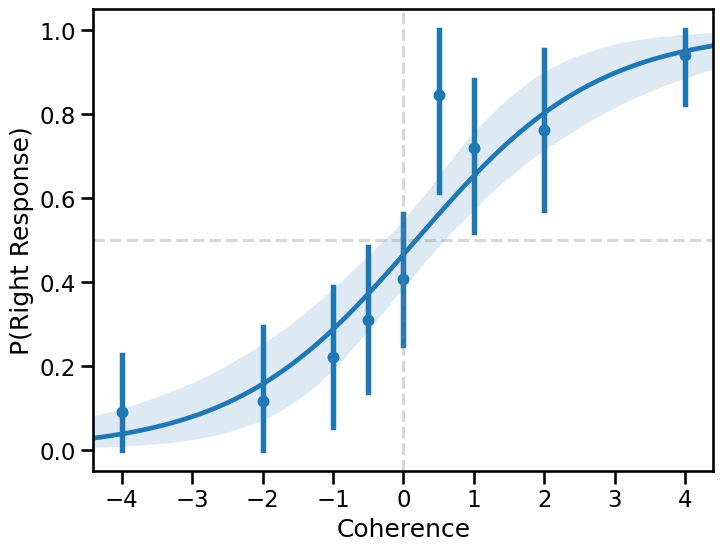

In [ ]:
# use such function with all data
plt.figure(figsize=(8, 6))
sns.set_context("talk")

plot_psychometric(df['coherence'],df['R_response'])
plt.xlabel("Coherence")
plt.ylabel("P(Right Response)")
plt.show()
# try to understand the plot. Are you biased?

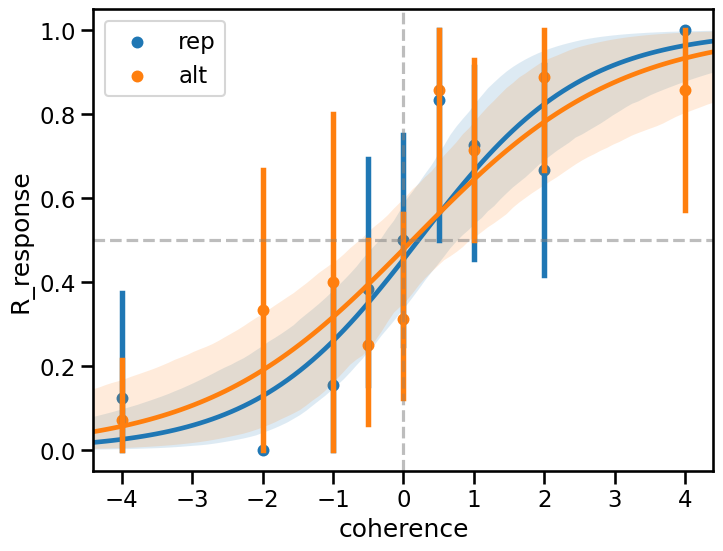

In [ ]:
# what if we split by block? do you expect any difference?
plt.figure(figsize=(8, 6))
sns.set_context("talk")


for block in ['rep', 'alt']:
    subset = df[df['block_type'] == block]  #
    plot_psychometric(subset['coherence'], subset['R_response'], label=block)

plt.legend()
plt.show()

In [ ]:
# no major differences in P(right) vs coherence (left-right)
# what if we realign it to show P(repeat) vs evidence to repeat?

# add evidence to repeat and rep_response to our dataframe first
def _add_ev_repeat_and_rep_response(df: pd.DataFrame) -> pd.DataFrame:
    '''Function to calc evidence to repeat

    it expects former function output as an input df
    '''
    # evidence_repeat = coherence (L~R in -1~1 space) *
    #        correct_side_t-1 in (L~R in -1~1 space )
    df['ev_repeat'] = df['coherence'] * df["correct_side"].map(
        {"left": -1, "right": 1}
    ).shift(1)

    # rep response = resp.keys == resp.keys at t-1
    df['rep_response'] = (df['resp.keys'] == df['resp.keys'].shift(1)) * 1.0
    df.loc[1, "rep_response"] = pd.NA  # 1st trial is not a repetition nor an alternation

    return df


df = _add_ev_repeat_and_rep_response(df)

In [ ]:
# review it makes sense
df[["correct_side", "resp.keys", "R_response", "is_rep","coherence", "ev_repeat"]].head(10)

,correct_side,resp.keys,R_response,is_rep,coherence,ev_repeat
1,right,NaN,NaN,NaN,1.0,NaN
2,right,NaN,NaN,1.0,0.5,0.5
3,right,NaN,NaN,1.0,2.0,2.0
4,left,right,1.0,0.0,-0.5,-0.5
5,right,NaN,NaN,0.0,0.0,-0.0
6,right,right,1.0,1.0,4.0,4.0
7,left,right,1.0,0.0,0.0,0.0
8,right,right,1.0,0.0,0.5,-0.5
9,left,right,1.0,0.0,0.0,0.0
10,right,right,1.0,0.0,1.0,-1.0


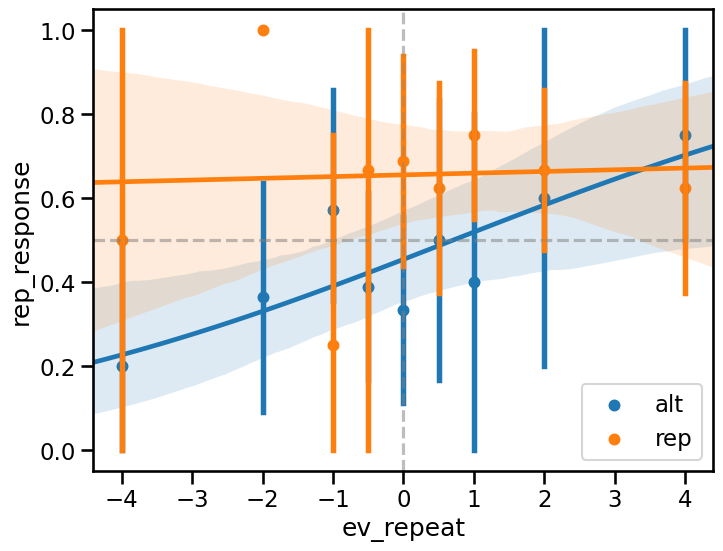

In [ ]:
# now plot P(repeat) vs evidence to repeat

plt.figure(figsize=(8, 6))
sns.set_context("talk")


for block in df['block_type'].unique():
    subset = df[df['block_type'] == block]
    plot_psychometric(subset['ev_repeat'], subset['rep_response'], label=block)

plt.legend()
plt.show()

In [ ]:
# okay, if you check the fit and the lines are extremely bad.
# (seems I am very bad at alternating blocks)
# if you check points at x=0 you can get the point.
# with lack of real evidence, we (and other animals) use biases to
# guide our choices

Tachometric curve
(we do this as an aggregate because we need more datapoints)

In [ ]:
df = pd.concat(  # agg all group data ~ we'll see how to share it
    [load_2afc_csv(x).pipe(_add_ev_repeat_and_rep_response) for x in files],
    ignore_index=True
)

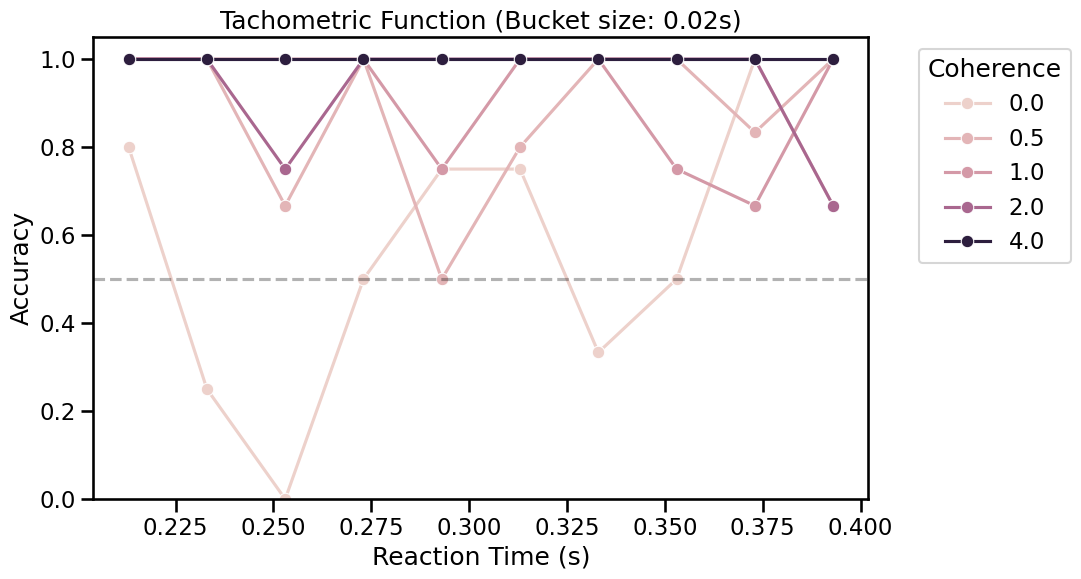

In [ ]:
def plot_tachometric(coherence, rt, correct, bucket_size=0.1, ax=None):
    """
    Plots tachometric functions: accuracy vs RT buckets for different coherence levels.

    Args:
        coherence (pd.Series): Series of coherence values.
        rt (pd.Series): Series of reaction times.
        correct (pd.Series): Series of accuracy (0 or 1).
        bucket_size (float): The width of the RT bins.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    # Create a temporary dataframe for grouping
    temp_df = pd.DataFrame({
        'coherence': coherence,
        'rt': rt,
        'correct': correct
    }).dropna(subset=['rt'])

    # Define bins based on the bucket size
    min_rt, max_rt = temp_df['rt'].min(), temp_df['rt'].max()
    bins = np.arange(min_rt, max_rt + bucket_size, bucket_size)

    # Create buckets
    temp_df['rt_bucket'] = pd.cut(temp_df['rt'], bins=bins).apply(lambda x: x.mid)

    # Calculate mean accuracy per coherence and bucket
    summary = temp_df.groupby(['coherence', 'rt_bucket'], observed=True)['correct'].mean().reset_index()

    # Plot using seaborn
    sns.lineplot(
        data=summary,
        x='rt_bucket',
        y='correct',
        hue='coherence',
        marker='o',
        ax=ax
    )

    ax.set_xlabel('Reaction Time (s)')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Tachometric Function (Bucket size: {bucket_size}s)')
    ax.axhline(0.5, color='black', linestyle='--', alpha=0.3)
    ax.set_ylim(0, 1.05)
    plt.legend(title='Coherence', bbox_to_anchor=(1.05, 1), loc='upper left')
    return ax


plot_tachometric(df['coherence'].abs(), df['stim_dur'], df['resp.corr'], bucket_size=0.02)
plt.show()

In [ ]:
# interpret tachometric